In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/iot_telemetry_data.csv',
                 names=['ts','device','co','humidity','light',
                        'lpg','motion','smoke','temp'],
                 skiprows=1)
df['ts'] = pd.to_datetime(df['ts'].astype(float), unit='s')
df = df.sort_values(['device', 'ts'])
df = df.set_index(['device', 'ts'])
df['motion'] = df['motion'].astype(bool)
df['light'] = df['light'].astype(bool)
print("Data loaded:", df.shape)

Data loaded: (405183, 7)


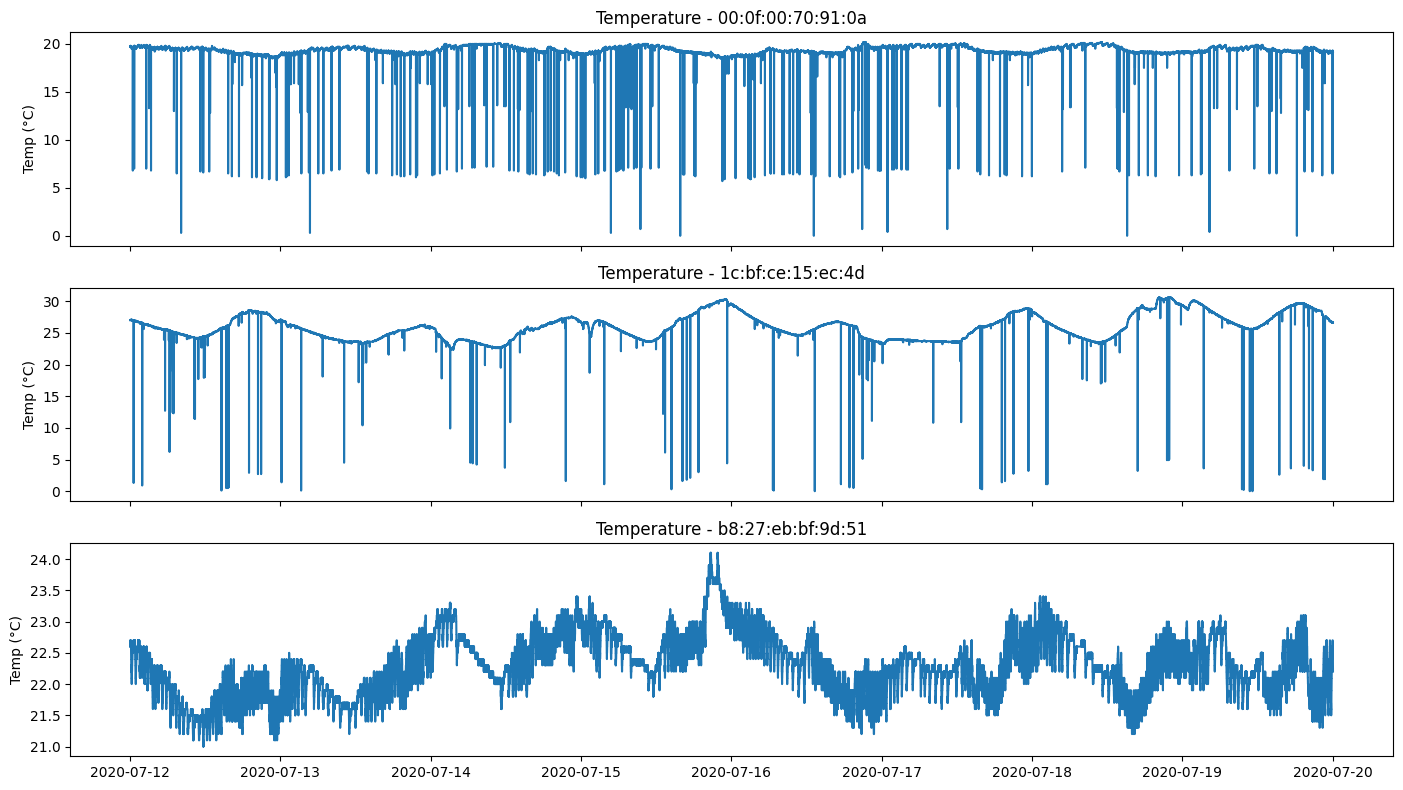

In [2]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for ax, (device, group) in zip(axes, df.groupby('device')):
    ax.plot(group.index.get_level_values('ts'), group['temp'])
    ax.set_title(f'Temperature - {device}')
    ax.set_ylabel('Temp (°C)')

plt.tight_layout()
plt.savefig('../data/temperature_plot.png')
plt.show()

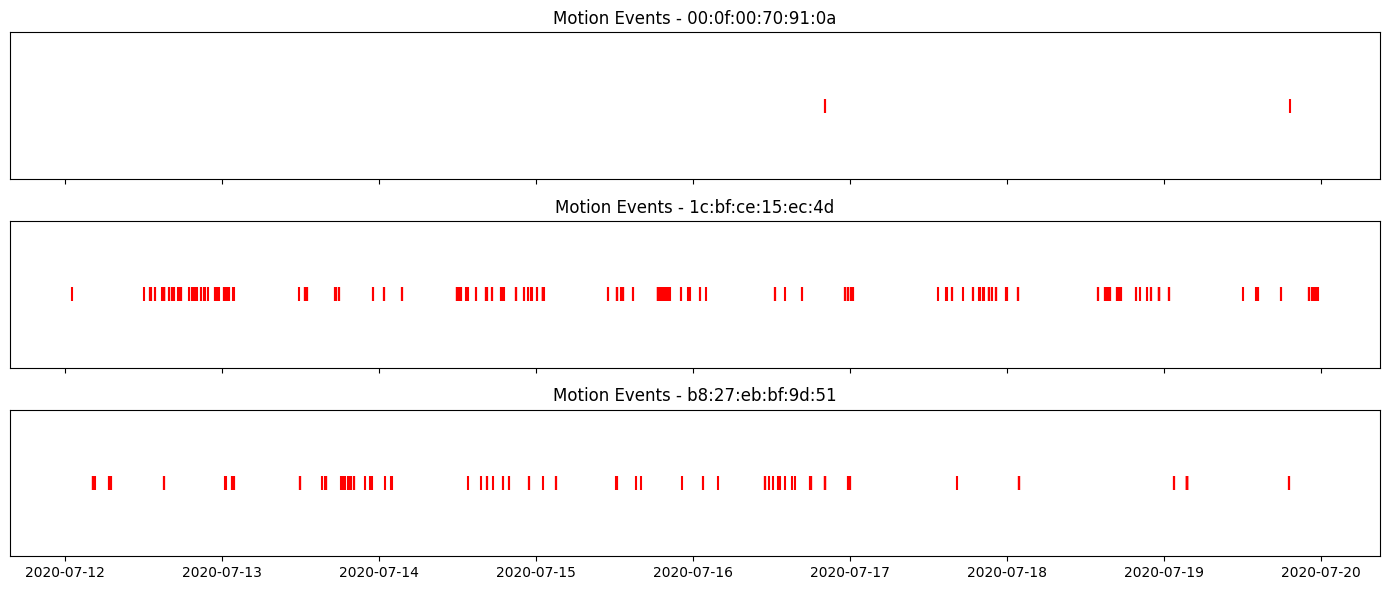

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)

for ax, (device, group) in zip(axes, df.groupby('device')):
    motion_times = group[group['motion'] == True].index.get_level_values('ts')
    ax.scatter(motion_times, [1]*len(motion_times), marker='|', color='red', s=100)
    ax.set_title(f'Motion Events - {device}')
    ax.set_yticks([])

plt.tight_layout()
plt.savefig('../data/motion_events_plot.png')
plt.show()

In [4]:
print("=== Motion Event Counts Per Device ===")
print(df.groupby('device')['motion'].sum())

print("\n=== Overall Stats ===")
print(df.describe())

=== Motion Event Counts Per Device ===
device
00:0f:00:70:91:0a      3
1c:bf:ce:15:ec:4d    335
b8:27:eb:bf:9d:51    144
Name: motion, dtype: int64

=== Overall Stats ===
                  co       humidity            lpg          smoke  \
count  405183.000000  405183.000000  405183.000000  405183.000000   
mean        0.004639      60.511717       0.007237       0.019264   
std         0.001250      11.366494       0.001444       0.004086   
min         0.001171       1.100000       0.002693       0.006692   
25%         0.003919      51.000000       0.006456       0.017024   
50%         0.004812      54.900000       0.007489       0.019950   
75%         0.005409      74.300003       0.008150       0.021838   
max         0.014420      99.900002       0.016567       0.046590   

                temp  
count  405183.000000  
mean       22.453987  
std         2.698350  
min         0.000000  
25%        19.900000  
50%        22.200000  
75%        23.600000  
max        30.600000  
